# Assignment 3 — Experimentation & Expansion
## Social Media Popularity Prediction: Sentence-BERT Gated Fusion Network

**Group Members:** 23i-2615 | 23i-2631 | 23i-2568

---

### What We Are Doing

In Assignment 2, we fine-tuned Qwen2-1.5B with LoRA for social media popularity prediction — achieving SPR=-0.0357 due to compute constraints (only 800 steps on a T4 GPU instead of 8 full epochs).

**Key Problem with Assignment 2 approach:** Qwen2 is a generative LLM — it is not designed for producing regression-quality embeddings, and full fine-tuning requires far more compute than available.

**Assignment 3 Fix:** Replace the LLM approach with `all-MiniLM-L6-v2` (Sentence-BERT) — a 22M-parameter model trained specifically for semantic similarity — combined with a Gated Fusion Network for structured numerical features.

| Model | Description |
|---|---|
| **Baseline 1** | MLP on numerical features only (SMPD) |
| **Baseline 2** | Sentence-BERT embeddings → MLP (SMPD) |
| **Proposed** | Sentence-BERT + numerical → Gated Fusion MLP (SMPD) |
| **Cross-Domain** | Same Proposed model trained on YouTube Dataset (HuggingFace) |

### Hypothesis
1. Sentence-BERT embeddings (designed for semantic tasks) will outperform frozen Qwen2 embeddings for popularity prediction.
2. Gated Fusion (text + numerical) will outperform either modality alone.
3. The fusion approach generalizes across domains (Flickr SMPD → YouTube).

---

## Step 0: Install Dependencies

In [1]:
!pip install -q sentence-transformers==3.0.1 datasets transformers scipy scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.3 MB/s eta 0:00:00


## Step 1: Load SMPD Data

In [1]:
import zipfile, os

with zipfile.ZipFile('train_allmetadata_json.zip', 'r') as z:
    z.extractall('train_metadata')
with zipfile.ZipFile('test_allmetadata_json.zip', 'r') as z:
    z.extractall('test_metadata')
print('Extraction done!')

Extraction done!


In [2]:
import pandas as pd
import json, glob, numpy as np

json_files = glob.glob('train_metadata/**/*.json', recursive=True)
frames = []
for f in json_files:
    with open(f) as fp:
        data = json.load(fp)
        frames.append(pd.DataFrame.from_dict(data).reset_index(drop=True))

df = pd.concat(frames, axis=1)
df = df.loc[:, ~df.columns.duplicated()]

with open('train_label.txt') as f:
    labels = [float(x.strip()) for x in f.readlines()]
df['label'] = labels[:len(df)]

# Parse datetime
df['Postdate_dt'] = pd.to_datetime(df['Postdate'], unit='s', errors='coerce')

print(f'SMPD dataset shape: {df.shape}')
df.head(2)

/tmp/ipykernel_2278/4280548873.py:19: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['Postdate_dt'] = pd.to_datetime(df['Postdate'], unit='s', errors='coerce')


SMPD dataset shape: (305613, 25)


,Category,Concept,Pid,Uid,Subcategory,photo_firstdate,photo_count,ispro,timezone_offset,photo_firstdatetaken,...,Title,Postdate,Longitude,Geoaccuracy,Latitude,Mediastatus,Pathalias,Ispublic,label,Postdate_dt
0,Fashion,glam,775,59@N75,Fashion,None,1429.0,1.0,None,1994-01-01 19:36:55,...,Luis Drayton - Edinburgh shoot #6,1446016778,,0,0,ready,luisdrayton,1,11.18,2015-10-28 07:19:38
1,Travel&Active&Sports,fifa,1075,1@N18,Soccer,None,43108.0,0.0,-03:00,1980-01-01 00:00:23,...,Arena da Barra - Arena HSBC - Arena do PAN #...,1454983379,,0,0,ready,claudiolara,1,15.15,2016-02-09 02:02:59


## Step 2: Feature Engineering — SMPD

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

def build_numerical_features(df):
    feat = pd.DataFrame()
    feat['is_pro']          = (df['ispro'].astype(str).str.lower() == 'true').astype(float)
    feat['photo_count']     = pd.to_numeric(df['photo_count'], errors='coerce').fillna(0)
    feat['photo_count_log'] = np.log1p(feat['photo_count'])
    feat['title_len']       = df['Title'].astype(str).str.len()
    feat['title_words']     = df['Title'].astype(str).str.split().str.len()
    feat['title_has_q']     = df['Title'].astype(str).str.contains(r'\?').astype(float)
    feat['title_has_excl']  = df['Title'].astype(str).str.contains('!').astype(float)
    feat['tag_count']       = df['Alltags'].astype(str).str.split().str.len().fillna(0)
    feat['hour']            = df['Postdate_dt'].dt.hour.fillna(0)
    feat['day_of_week']     = df['Postdate_dt'].dt.dayofweek.fillna(0)
    feat['month']           = df['Postdate_dt'].dt.month.fillna(0)
    feat['is_weekend']      = (feat['day_of_week'] >= 5).astype(float)
    feat['is_peak_hour']    = feat['hour'].isin([8,9,10,18,19,20,21]).astype(float)

    le = LabelEncoder()
    feat['category_enc']    = le.fit_transform(df['Category'].astype(str))
    feat['subcategory_enc'] = le.fit_transform(df['Subcategory'].astype(str))
    feat['mediatype_enc']   = le.fit_transform(df['Mediatype'].astype(str))

    arr = feat.values.astype(np.float32)
    arr = np.nan_to_num(arr)
    scaler = StandardScaler()
    arr = scaler.fit_transform(arr)
    return arr, feat.columns.tolist()

num_feat_full, feat_names = build_numerical_features(df)
print(f'Numerical feature matrix: {num_feat_full.shape}')
print(f'Features: {feat_names}')

Numerical feature matrix: (305613, 16)
Features: ['is_pro', 'photo_count', 'photo_count_log', 'title_len', 'title_words', 'title_has_q', 'title_has_excl', 'tag_count', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'category_enc', 'subcategory_enc', 'mediatype_enc']


In [4]:
def build_text_prompt_smpd(row):
    r = row.fillna('Not Available')
    pro_str = 'pro' if str(r['ispro']).lower() == 'true' else 'regular'
    return (
        f'A {pro_str} user who has uploaded {r["photo_count"]} photos '
        f'posted a {r["Mediatype"]} titled "{r["Title"]}". '
        f'Category: {r["Category"]}, Concept: {r["Concept"]}. '
        f'Tags: {r["Alltags"]}. Published at {r["Postdate_dt"]}.'
    )

print('Building SMPD text prompts...')
df['text_prompt'] = df.apply(build_text_prompt_smpd, axis=1)
print('Sample:', df['text_prompt'].iloc[0])

Building SMPD text prompts...
Sample: A regular user who has uploaded 1429.0 photos posted a photo titled "Luis Drayton - Edinburgh shoot #6". Category: Fashion, Concept: glam. Tags: rock punk transgender tranny electronicmusic electro glam electronica luisdrayton fusionrecords thefusionnetwork lmwcphotography. Published at 2015-10-28 07:19:38.


## Step 3: Sample & Split SMPD

In [5]:
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = 486000
sample_df = df.dropna(subset=['label']).sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)

num_feat_sample, _ = build_numerical_features(sample_df)
labels_sample = sample_df['label'].values.astype(np.float32)
texts_sample  = sample_df['text_prompt'].tolist()

# Remove NaNs
valid = ~np.isnan(labels_sample)
num_feat_sample = num_feat_sample[valid]
labels_sample   = labels_sample[valid]
texts_sample    = [t for t, v in zip(texts_sample, valid) if v]

print(f'Clean samples: {len(labels_sample)}')

idx = np.arange(len(labels_sample))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
idx_train, idx_val  = train_test_split(idx_train, test_size=0.1, random_state=42)
print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')

Clean samples: 305613
Train: 220041 | Val: 24449 | Test: 61123


## Step 4: Extract Sentence-BERT Embeddings

**Why Sentence-BERT?**
- Assignment 2 used Qwen2-1.5B (generative LLM, 1.5B params) — not designed for producing semantic embeddings
- `all-MiniLM-L6-v2` = 22M params, trained specifically for semantic similarity via contrastive learning — **far more suitable for regression tasks**

In [6]:
from sentence_transformers import SentenceTransformer

print('Loading Sentence-BERT: all-MiniLM-L6-v2 (22M params — fast!)')
sbert = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded!')
print(f'Embedding dim: 384')

/usr/local/lib/python3.12/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


Loading Sentence-BERT: all-MiniLM-L6-v2 (22M params — fast!)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!
Embedding dim: 384


In [7]:
import os

EMB_FILE  = 'sbert_embeddings_smpd.npy'
NUM_FILE  = 'num_features_smpd.npy'
LAB_FILE  = 'labels_smpd.npy'

if os.path.exists(EMB_FILE):
    print('Loading saved embeddings...')
    text_emb   = np.load(EMB_FILE)
    num_feat   = np.load(NUM_FILE)
    labels_arr = np.load(LAB_FILE)
    # Rebuild splits from saved arrays
    idx = np.arange(len(labels_arr))
    idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
    idx_train, idx_val  = train_test_split(idx_train, test_size=0.1, random_state=42)
else:
    print(f'Extracting SBERT embeddings for {len(texts_sample)} samples...')
    # batch_size=128 — much faster than Qwen2's 32
    text_emb = sbert.encode(
        texts_sample,
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    num_feat   = num_feat_sample
    labels_arr = labels_sample

    np.save(EMB_FILE,  text_emb)
    np.save(NUM_FILE,  num_feat)
    np.save(LAB_FILE,  labels_arr)
    print('Saved!')

print(f'Text embeddings : {text_emb.shape}')   # (N, 384)
print(f'Numerical feats : {num_feat.shape}')   # (N, 16)
print(f'Labels          : {labels_arr.shape}')

Extracting SBERT embeddings for 305613 samples...


Batches:   0%|          | 0/2388 [00:00<?, ?it/s]

Saved!
Text embeddings : (305613, 384)
Numerical feats : (305613, 16)
Labels          : (305613,)


## Step 5: Prepare Train/Val/Test Arrays

In [8]:
X_text_train = text_emb[idx_train].astype(np.float32)
X_text_val   = text_emb[idx_val].astype(np.float32)
X_text_test  = text_emb[idx_test].astype(np.float32)

X_num_train  = num_feat[idx_train].astype(np.float32)
X_num_val    = num_feat[idx_val].astype(np.float32)
X_num_test   = num_feat[idx_test].astype(np.float32)

y_train = labels_arr[idx_train].astype(np.float32)
y_val   = labels_arr[idx_val].astype(np.float32)
y_test  = labels_arr[idx_test].astype(np.float32)

TEXT_DIM = X_text_train.shape[1]  # 384
NUM_DIM  = X_num_train.shape[1]   # 16
print(f'TEXT_DIM={TEXT_DIM}, NUM_DIM={NUM_DIM}')
print(f'Train={len(y_train)}, Val={len(y_val)}, Test={len(y_test)}')

TEXT_DIM=384, NUM_DIM=16
Train=220041, Val=24449, Test=61123


## Step 6: Define All Three Models

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


# ============================================================
# BASELINE 1: MLP on Numerical Features Only
# ============================================================
class NumericalMLP(nn.Module):
    def __init__(self, num_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),     nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),      nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x_num):
        return self.net(x_num).squeeze(-1)


# ============================================================
# BASELINE 2: Sentence-BERT Embeddings -> MLP
# ============================================================
class TextEmbeddingMLP(nn.Module):
    def __init__(self, text_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(text_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),      nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128),      nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x_text):
        return self.net(x_text).squeeze(-1)


# ============================================================
# PROPOSED: Gated Cross-Modal Fusion Network
# Text proj + Num proj -> Gating -> Fusion -> Prediction
# ============================================================
class GatedFusionNet(nn.Module):
    def __init__(self, text_dim, num_dim, hidden=256):
        super().__init__()
        # Project each modality to same hidden size
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.3)
        )
        self.num_proj = nn.Sequential(
            nn.Linear(num_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.3)
        )
        # Gating: learn how much to weight each modality per sample
        self.gate = nn.Sequential(
            nn.Linear(hidden * 2, hidden * 2),
            nn.Sigmoid()  # outputs values in (0,1) for each feature
        )
        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 64),         nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_text, x_num):
        t = self.text_proj(x_text)   # (B, hidden)
        n = self.num_proj(x_num)     # (B, hidden)
        combined = torch.cat([t, n], dim=1)  # (B, hidden*2)
        gate_weights = self.gate(combined)   # (B, hidden*2) — learned importance
        gated = combined * gate_weights      # element-wise gating
        return self.head(gated).squeeze(-1)


# Instantiate
model_b1       = NumericalMLP(NUM_DIM).to(DEVICE)
model_b2       = TextEmbeddingMLP(TEXT_DIM).to(DEVICE)
model_proposed = GatedFusionNet(TEXT_DIM, NUM_DIM).to(DEVICE)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'Baseline 1 (NumericalMLP)     params: {count_params(model_b1):,}')
print(f'Baseline 2 (TextEmbeddingMLP) params: {count_params(model_b2):,}')
print(f'Proposed   (GatedFusion)      params: {count_params(model_proposed):,}')

Using device: cuda
Baseline 1 (NumericalMLP)     params: 46,337
Baseline 2 (TextEmbeddingMLP) params: 363,009
Proposed   (GatedFusion)      params: 514,945


## Step 7: Training Utilities

In [10]:
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

def make_loader(arrays, labels, batch_size=256, shuffle=True):
    tensors = [torch.FloatTensor(a) for a in arrays]
    tensors.append(torch.FloatTensor(labels))
    ds = TensorDataset(*tensors)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_arrays, val_arrays, y_train, y_val,
                model_name='Model', epochs=50, lr=1e-3, patience=7):
    train_loader = make_loader(train_arrays, y_train)
    val_loader   = make_loader(val_arrays, y_val, shuffle=False)
    optimizer  = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion  = nn.HuberLoss(delta=1.0)  # More robust than MSE for outliers
    history    = {'train_loss': [], 'val_loss': [], 'val_spr': []}
    best_val_spr   = -1
    patience_count = 0
    best_state     = None

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        t_loss = 0
        for batch in train_loader:
            *inputs, target = [b.to(DEVICE) for b in batch]
            optimizer.zero_grad()
            out = model(*inputs)
            loss = criterion(out, target)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()
        t_loss /= len(train_loader)

        # Validate
        model.eval()
        preds_all, targets_all, v_loss = [], [], 0
        with torch.no_grad():
            for batch in val_loader:
                *inputs, target = [b.to(DEVICE) for b in batch]
                out = model(*inputs)
                v_loss += criterion(out, target).item()
                preds_all.extend(out.cpu().numpy())
                targets_all.extend(target.cpu().numpy())
        v_loss /= len(val_loader)
        spr = spearmanr(targets_all, preds_all).statistic

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['val_spr'].append(spr)

        if epoch % 5 == 0 or epoch == 1:
            print(f'[{model_name}] Epoch {epoch:02d}/{epochs} | Train: {t_loss:.4f} | Val: {v_loss:.4f} | SPR: {spr:.4f}')

        # Early stopping on SPR (higher = better)
        if spr > best_val_spr:
            best_val_spr   = spr
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

        scheduler.step()

    model.load_state_dict(best_state)
    print(f'  Best Val SPR: {best_val_spr:.4f}')
    return history


def evaluate_model(model, test_arrays, y_test, name):
    model.eval()
    loader = make_loader(test_arrays, y_test, shuffle=False)
    preds, tgts = [], []
    with torch.no_grad():
        for batch in loader:
            *inputs, target = [b.to(DEVICE) for b in batch]
            preds.extend(model(*inputs).cpu().numpy())
            tgts.extend(target.cpu().numpy())
    spr  = spearmanr(tgts, preds).statistic
    mae  = mean_absolute_error(tgts, preds)
    mse  = mean_squared_error(tgts, preds)
    rmse = np.sqrt(mse)
    print(f'\n--- {name} ---')
    print(f'SPR  : {spr:.4f}   (paper: 0.8866)')
    print(f'MAE  : {mae:.4f}   (paper: 0.6432)')
    print(f'MSE  : {mse:.4f}   (paper: 1.4223)')
    print(f'RMSE : {rmse:.4f}')
    return {'model': name, 'SPR': spr, 'MAE': mae, 'MSE': mse, 'RMSE': rmse,
            'preds': preds, 'targets': tgts}

print('Training utilities ready!')

Training utilities ready!


## Step 8: Train Baseline 1 — NumericalMLP (SMPD)

In [11]:
history_b1 = train_model(
    model_b1,
    train_arrays=[X_num_train], val_arrays=[X_num_val],
    y_train=y_train, y_val=y_val,
    model_name='Baseline1-NumericalMLP',
    epochs=60, lr=1e-3, patience=10
)

[Baseline1-NumericalMLP] Epoch 01/60 | Train: 1.4760 | Val: 1.3025 | SPR: 0.4571
[Baseline1-NumericalMLP] Epoch 05/60 | Train: 1.2391 | Val: 1.1622 | SPR: 0.5424
[Baseline1-NumericalMLP] Epoch 10/60 | Train: 1.1622 | Val: 1.0789 | SPR: 0.5885
[Baseline1-NumericalMLP] Epoch 15/60 | Train: 1.1133 | Val: 1.0444 | SPR: 0.6211
[Baseline1-NumericalMLP] Epoch 20/60 | Train: 1.0837 | Val: 0.9982 | SPR: 0.6421
[Baseline1-NumericalMLP] Epoch 25/60 | Train: 1.0622 | Val: 0.9706 | SPR: 0.6534
[Baseline1-NumericalMLP] Epoch 30/60 | Train: 1.0474 | Val: 0.9529 | SPR: 0.6643
[Baseline1-NumericalMLP] Epoch 35/60 | Train: 1.0326 | Val: 0.9542 | SPR: 0.6675
[Baseline1-NumericalMLP] Epoch 40/60 | Train: 1.0266 | Val: 0.9305 | SPR: 0.6723
[Baseline1-NumericalMLP] Epoch 45/60 | Train: 1.0195 | Val: 0.9285 | SPR: 0.6764
[Baseline1-NumericalMLP] Epoch 50/60 | Train: 1.0124 | Val: 0.9257 | SPR: 0.6779
[Baseline1-NumericalMLP] Epoch 55/60 | Train: 1.0098 | Val: 0.9216 | SPR: 0.6775
[Baseline1-NumericalMLP] Epo

## Step 9: Train Baseline 2 — SentenceBERT MLP (SMPD)

In [12]:
history_b2 = train_model(
    model_b2,
    train_arrays=[X_text_train], val_arrays=[X_text_val],
    y_train=y_train, y_val=y_val,
    model_name='Baseline2-SBERTembMLP',
    epochs=60, lr=5e-4, patience=10
)

[Baseline2-SBERTembMLP] Epoch 01/60 | Train: 1.0140 | Val: 0.9050 | SPR: 0.7660
[Baseline2-SBERTembMLP] Epoch 05/60 | Train: 0.6613 | Val: 0.6478 | SPR: 0.8198
[Baseline2-SBERTembMLP] Epoch 10/60 | Train: 0.5815 | Val: 0.7112 | SPR: 0.8383
[Baseline2-SBERTembMLP] Epoch 15/60 | Train: 0.5320 | Val: 0.7134 | SPR: 0.8454
[Baseline2-SBERTembMLP] Epoch 20/60 | Train: 0.4908 | Val: 0.6477 | SPR: 0.8537
[Baseline2-SBERTembMLP] Epoch 25/60 | Train: 0.4590 | Val: 0.6146 | SPR: 0.8552
[Baseline2-SBERTembMLP] Epoch 30/60 | Train: 0.4318 | Val: 0.6509 | SPR: 0.8564
[Baseline2-SBERTembMLP] Epoch 35/60 | Train: 0.4106 | Val: 0.6353 | SPR: 0.8580
[Baseline2-SBERTembMLP] Epoch 40/60 | Train: 0.3941 | Val: 0.6629 | SPR: 0.8581
[Baseline2-SBERTembMLP] Epoch 45/60 | Train: 0.3803 | Val: 0.6518 | SPR: 0.8593
[Baseline2-SBERTembMLP] Epoch 50/60 | Train: 0.3737 | Val: 0.6837 | SPR: 0.8588
[Baseline2-SBERTembMLP] Epoch 55/60 | Train: 0.3663 | Val: 0.6409 | SPR: 0.8593
[Baseline2-SBERTembMLP] Epoch 60/60 | Tr

## Step 10: Train Proposed — Gated Fusion (SMPD)

In [13]:
history_proposed = train_model(
    model_proposed,
    train_arrays=[X_text_train, X_num_train],
    val_arrays=[X_text_val, X_num_val],
    y_train=y_train, y_val=y_val,
    model_name='Proposed-GatedFusion',
    epochs=60, lr=5e-4, patience=10
)

[Proposed-GatedFusion] Epoch 01/60 | Train: 1.0989 | Val: 0.8959 | SPR: 0.7730
[Proposed-GatedFusion] Epoch 05/60 | Train: 0.6442 | Val: 0.7391 | SPR: 0.8363
[Proposed-GatedFusion] Epoch 10/60 | Train: 0.5603 | Val: 0.6595 | SPR: 0.8504
[Proposed-GatedFusion] Epoch 15/60 | Train: 0.5085 | Val: 0.6522 | SPR: 0.8608
[Proposed-GatedFusion] Epoch 20/60 | Train: 0.4733 | Val: 0.6118 | SPR: 0.8664
[Proposed-GatedFusion] Epoch 25/60 | Train: 0.4431 | Val: 0.5829 | SPR: 0.8687
[Proposed-GatedFusion] Epoch 30/60 | Train: 0.4193 | Val: 0.5779 | SPR: 0.8721
[Proposed-GatedFusion] Epoch 35/60 | Train: 0.4006 | Val: 0.5782 | SPR: 0.8719
[Proposed-GatedFusion] Epoch 40/60 | Train: 0.3853 | Val: 0.5906 | SPR: 0.8730
[Proposed-GatedFusion] Epoch 45/60 | Train: 0.3720 | Val: 0.5764 | SPR: 0.8739
[Proposed-GatedFusion] Epoch 50/60 | Train: 0.3660 | Val: 0.5774 | SPR: 0.8741
[Proposed-GatedFusion] Epoch 55/60 | Train: 0.3639 | Val: 0.5515 | SPR: 0.8745
[Proposed-GatedFusion] Epoch 60/60 | Train: 0.3604 |

## Step 11: Evaluate All Models on SMPD Test Set

In [14]:
results_b1       = evaluate_model(model_b1,       [X_num_test],              y_test, 'Baseline1 - NumericalMLP')
results_b2       = evaluate_model(model_b2,       [X_text_test],             y_test, 'Baseline2 - SentenceBERT MLP')
results_proposed = evaluate_model(model_proposed, [X_text_test, X_num_test], y_test, 'Proposed  - Gated Fusion')


--- Baseline1 - NumericalMLP ---
SPR  : 0.6774   (paper: 0.8866)
MAE  : 1.2927   (paper: 0.6432)
MSE  : 3.4946   (paper: 1.4223)
RMSE : 1.8694

--- Baseline2 - SentenceBERT MLP ---
SPR  : 0.8573   (paper: 0.8866)
MAE  : 1.0472   (paper: 0.6432)
MSE  : 2.2590   (paper: 1.4223)
RMSE : 1.5030

--- Proposed  - Gated Fusion ---
SPR  : 0.8723   (paper: 0.8866)
MAE  : 0.9694   (paper: 0.6432)
MSE  : 2.0165   (paper: 1.4223)
RMSE : 1.4200


---
## Step 12: Additional Dataset — YouTube (HuggingFace)

**Cross-domain generalization test:**
Train the same Gated Fusion architecture on a completely different platform (YouTube videos).
This tests whether our method generalizes beyond Flickr photos.

**Dataset:** `YouTube-Dataset` — YouTube videos with title, description, view_count, likes, comments, category.
We predict **log(view_count)** as the popularity score — analogous to SMPD's log-scale label.

In [15]:
import pandas as pd
import numpy as np

print('Loading YouTube Trending dataset...')

import os

LOCAL_CSV = 'USvideos.csv'
if os.path.exists(LOCAL_CSV):
    yt_df = pd.read_csv(LOCAL_CSV)
    print(f'Loaded from local CSV: {yt_df.shape}')
    print(f'Columns: {yt_df.columns.tolist()}')

    rename_map = {}
    if 'views'        in yt_df.columns: rename_map['views']        = 'view_count'
    if 'likes'        in yt_df.columns: rename_map['likes']        = 'like_count'
    if 'comment_count' not in yt_df.columns and 'comments' in yt_df.columns:
        rename_map['comments'] = 'comment_count'
    if 'category_id'  in yt_df.columns: rename_map['category_id']  = 'categoryId'
    if 'publish_time' in yt_df.columns: rename_map['publish_time'] = 'publishedAt'

    if rename_map:
        yt_df = yt_df.rename(columns=rename_map)
        print(f'Renamed columns: {rename_map}')

else:
    print(f'USvideos.csv not found at "{LOCAL_CSV}"')

# ---- Ensure required columns exist ----
for col in ['view_count', 'like_count', 'comment_count']:
    if col not in yt_df.columns:
        yt_df[col] = 0
for col in ['title', 'tags', 'description']:
    if col not in yt_df.columns:
        yt_df[col] = ''
if 'categoryId' not in yt_df.columns:
    if 'category_id' in yt_df.columns:
        yt_df = yt_df.rename(columns={'category_id': 'categoryId'})
    else:
        yt_df['categoryId'] = 'Unknown'
if 'publishedAt' not in yt_df.columns:
    yt_df['publishedAt'] = '2019-01-01'

print(f'\nFinal YouTube dataset shape: {yt_df.shape}')
print(f'Columns available: {yt_df.columns.tolist()}')
yt_df.head(2)


Loading YouTube Trending dataset...
Loaded from local CSV: (40949, 16)
Columns: ['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description']
Renamed columns: {'views': 'view_count', 'likes': 'like_count', 'category_id': 'categoryId', 'publish_time': 'publishedAt'}

Final YouTube dataset shape: (40949, 16)
Columns available: ['video_id', 'trending_date', 'title', 'channel_title', 'categoryId', 'publishedAt', 'tags', 'view_count', 'like_count', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description']


,video_id,trending_date,title,channel_title,categoryId,publishedAt,tags,view_count,like_count,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."


In [16]:
# ---- Preprocess YouTube Data ----

# Target: log(view_count) — same scale as SMPD
yt_df['view_count']   = pd.to_numeric(yt_df['view_count'],   errors='coerce').fillna(0)
yt_df['like_count']   = pd.to_numeric(yt_df['like_count'],   errors='coerce').fillna(0)
yt_df['comment_count']= pd.to_numeric(yt_df['comment_count'],errors='coerce').fillna(0)
yt_df['label']        = np.log1p(yt_df['view_count'])  # log-scale popularity

# Remove rows with 0 views (unlisted/private)
yt_df = yt_df[yt_df['view_count'] > 0].reset_index(drop=True)
print(f'After filtering 0-view rows: {len(yt_df)}')
print(f'Label stats: mean={yt_df["label"].mean():.2f}, std={yt_df["label"].std():.2f}')

After filtering 0-view rows: 40949
Label stats: mean=13.34, std=1.71


In [17]:
# ---- YouTube Text Prompts ----
def build_text_prompt_yt(row):
    title = str(row.get('title', 'No Title'))[:100]
    desc  = str(row.get('description', ''))[:200]
    cat   = str(row.get('categoryId', 'Unknown'))
    tags  = str(row.get('tags', ''))[:100]
    return (
        f'YouTube video titled "{title}". '
        f'Category ID: {cat}. Tags: {tags}. '
        f'Description: {desc}'
    )

yt_df['text_prompt'] = yt_df.apply(build_text_prompt_yt, axis=1)
print('Sample YouTube prompt:')
print(yt_df['text_prompt'].iloc[0])

Sample YouTube prompt:
YouTube video titled "WE WANT TO TALK ABOUT OUR MARRIAGE". Category ID: 22. Tags: SHANtell martin. Description: SHANTELL'S CHANNEL - https://www.youtube.com/shantellmartin\nCANDICE - https://www.lovebilly.com\n\nfilmed this video in 4k on this -- http://amzn.to/2sTDnRZ\nwith this lens -- http://amzn.to/2rUJOmD\


In [18]:
# ---- YouTube Numerical Features ----
def build_numerical_features_yt(df):
    feat = pd.DataFrame()
    feat['like_count_log']    = np.log1p(df['like_count'])
    feat['comment_count_log'] = np.log1p(df['comment_count'])
    feat['like_per_comment']  = (df['like_count'] / (df['comment_count'] + 1)).clip(0, 1000)
    feat['title_len']         = df['title'].astype(str).str.len()
    feat['title_words']       = df['title'].astype(str).str.split().str.len()
    feat['title_has_q']       = df['title'].astype(str).str.contains(r'\?').astype(float)
    feat['title_has_excl']    = df['title'].astype(str).str.contains('!').astype(float)
    feat['title_caps_ratio']  = df['title'].astype(str).apply(
        lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
    feat['desc_len']          = df['description'].astype(str).str.len().clip(0, 5000)
    feat['has_tags']          = (df['tags'].astype(str) != '').astype(float)

    le = LabelEncoder()
    feat['category_enc']      = le.fit_transform(df['categoryId'].astype(str))

    # Published time features
    try:
        pub = pd.to_datetime(df['publishedAt'], errors='coerce')
        feat['pub_hour']       = pub.dt.hour.fillna(12)
        feat['pub_day_of_week']= pub.dt.dayofweek.fillna(0)
        feat['pub_month']      = pub.dt.month.fillna(6)
        feat['is_weekend']     = (feat['pub_day_of_week'] >= 5).astype(float)
    except:
        feat['pub_hour'] = feat['pub_day_of_week'] = feat['pub_month'] = feat['is_weekend'] = 0.0

    arr = feat.values.astype(np.float32)
    arr = np.nan_to_num(arr)
    scaler = StandardScaler()
    arr = scaler.fit_transform(arr)
    return arr

yt_num = build_numerical_features_yt(yt_df)
yt_labels = yt_df['label'].values.astype(np.float32)
yt_texts  = yt_df['text_prompt'].tolist()
print(f'YouTube numerical features: {yt_num.shape}')

YouTube numerical features: (40949, 15)


In [19]:
# ---- YouTube SBERT Embeddings ----
YT_EMB_FILE = 'sbert_embeddings_youtube.npy'

if os.path.exists(YT_EMB_FILE):
    print('Loading saved YouTube embeddings...')
    yt_text_emb = np.load(YT_EMB_FILE)
else:
    print(f'Extracting SBERT embeddings for {len(yt_texts)} YouTube samples...')
    yt_text_emb = sbert.encode(
        yt_texts, batch_size=128, show_progress_bar=True, convert_to_numpy=True
    )
    np.save(YT_EMB_FILE, yt_text_emb)
    print('Saved!')

print(f'YouTube text embeddings: {yt_text_emb.shape}')

Extracting SBERT embeddings for 40949 YouTube samples...


Batches:   0%|          | 0/320 [00:00<?, ?it/s]

Saved!
YouTube text embeddings: (40949, 384)


In [20]:
# ---- YouTube Train/Val/Test Split ----
idx_yt = np.arange(len(yt_labels))
idx_yt_train, idx_yt_test = train_test_split(idx_yt, test_size=0.2, random_state=42)
idx_yt_train, idx_yt_val  = train_test_split(idx_yt_train, test_size=0.1, random_state=42)

YT_NUM_DIM = yt_num.shape[1]
print(f'YouTube NUM_DIM={YT_NUM_DIM}')
print(f'YT Train={len(idx_yt_train)}, Val={len(idx_yt_val)}, Test={len(idx_yt_test)}')

YouTube NUM_DIM=15
YT Train=29483, Val=3276, Test=8190


## Step 13: Train Gated Fusion on YouTube Dataset

In [21]:
# Fresh model for YouTube (different num_dim)
model_yt = GatedFusionNet(TEXT_DIM, YT_NUM_DIM).to(DEVICE)
print(f'YouTube GatedFusion params: {count_params(model_yt):,}')

history_yt = train_model(
    model_yt,
    train_arrays=[
        yt_text_emb[idx_yt_train].astype(np.float32),
        yt_num[idx_yt_train].astype(np.float32)
    ],
    val_arrays=[
        yt_text_emb[idx_yt_val].astype(np.float32),
        yt_num[idx_yt_val].astype(np.float32)
    ],
    y_train=yt_labels[idx_yt_train],
    y_val=yt_labels[idx_yt_val],
    model_name='YouTube-GatedFusion',
    epochs=60, lr=5e-4, patience=10
)

YouTube GatedFusion params: 514,689
[YouTube-GatedFusion] Epoch 01/60 | Train: 6.1432 | Val: 2.6551 | SPR: 0.8307
[YouTube-GatedFusion] Epoch 05/60 | Train: 0.3981 | Val: 0.6092 | SPR: 0.9356
[YouTube-GatedFusion] Epoch 10/60 | Train: 0.3259 | Val: 0.2727 | SPR: 0.9560
[YouTube-GatedFusion] Epoch 15/60 | Train: 0.2833 | Val: 0.1544 | SPR: 0.9537
[YouTube-GatedFusion] Epoch 20/60 | Train: 0.2482 | Val: 0.1519 | SPR: 0.9725
[YouTube-GatedFusion] Epoch 25/60 | Train: 0.2210 | Val: 0.1972 | SPR: 0.9734
[YouTube-GatedFusion] Epoch 30/60 | Train: 0.2019 | Val: 0.1934 | SPR: 0.9782
[YouTube-GatedFusion] Epoch 35/60 | Train: 0.1834 | Val: 0.0855 | SPR: 0.9807
[YouTube-GatedFusion] Epoch 40/60 | Train: 0.1733 | Val: 0.1093 | SPR: 0.9827
[YouTube-GatedFusion] Epoch 45/60 | Train: 0.1699 | Val: 0.0599 | SPR: 0.9831
[YouTube-GatedFusion] Epoch 50/60 | Train: 0.1613 | Val: 0.0974 | SPR: 0.9846
[YouTube-GatedFusion] Epoch 55/60 | Train: 0.1575 | Val: 0.0732 | SPR: 0.9852
[YouTube-GatedFusion] Epoch 

In [22]:
results_yt = evaluate_model(
    model_yt,
    [
        yt_text_emb[idx_yt_test].astype(np.float32),
        yt_num[idx_yt_test].astype(np.float32)
    ],
    yt_labels[idx_yt_test],
    'YouTube - Gated Fusion (Cross-Domain)'
)


--- YouTube - Gated Fusion (Cross-Domain) ---
SPR  : 0.9849   (paper: 0.8866)
MAE  : 0.3791   (paper: 0.6432)
MSE  : 0.1999   (paper: 1.4223)
RMSE : 0.4471


## Step 14: Final Comparison Table

In [23]:
paper_result = {'model': 'Original Paper (Qwen2-7B LoRA)', 'SPR': 0.8866, 'MAE': 0.6432, 'MSE': 1.4223, 'RMSE': 1.1926}
a2_result    = {'model': 'Assignment 2 (Qwen2-1.5B LoRA, 800 steps)', 'SPR': -0.0357, 'MAE': 2.2178, 'MSE': 8.0837, 'RMSE': 2.8431}

all_results = [
    results_b1, results_b2, results_proposed,
    results_yt,
    a2_result,
    paper_result
]

results_df = pd.DataFrame([{
    'Model' : r['model'],
    'SPR'   : round(r['SPR'],  4),
    'MAE'   : round(r['MAE'],  4),
    'MSE'   : round(r['MSE'],  4),
    'RMSE'  : round(r['RMSE'], 4)
} for r in all_results])

print('=' * 80)
print('                      FINAL COMPARISON TABLE')
print('=' * 80)
print(results_df.to_string(index=False))
print('=' * 80)
print('SPR: higher is better | MAE / MSE / RMSE: lower is better')

                      FINAL COMPARISON TABLE
                                    Model     SPR    MAE    MSE   RMSE
                 Baseline1 - NumericalMLP  0.6774 1.2927 3.4946 1.8694
             Baseline2 - SentenceBERT MLP  0.8573 1.0472 2.2590 1.5030
                 Proposed  - Gated Fusion  0.8723 0.9694 2.0165 1.4200
    YouTube - Gated Fusion (Cross-Domain)  0.9849 0.3791 0.1999 0.4471
Assignment 2 (Qwen2-1.5B LoRA, 800 steps) -0.0357 2.2178 8.0837 2.8431
           Original Paper (Qwen2-7B LoRA)  0.8866 0.6432 1.4223 1.1926
SPR: higher is better | MAE / MSE / RMSE: lower is better


## Step 15: Visualizations

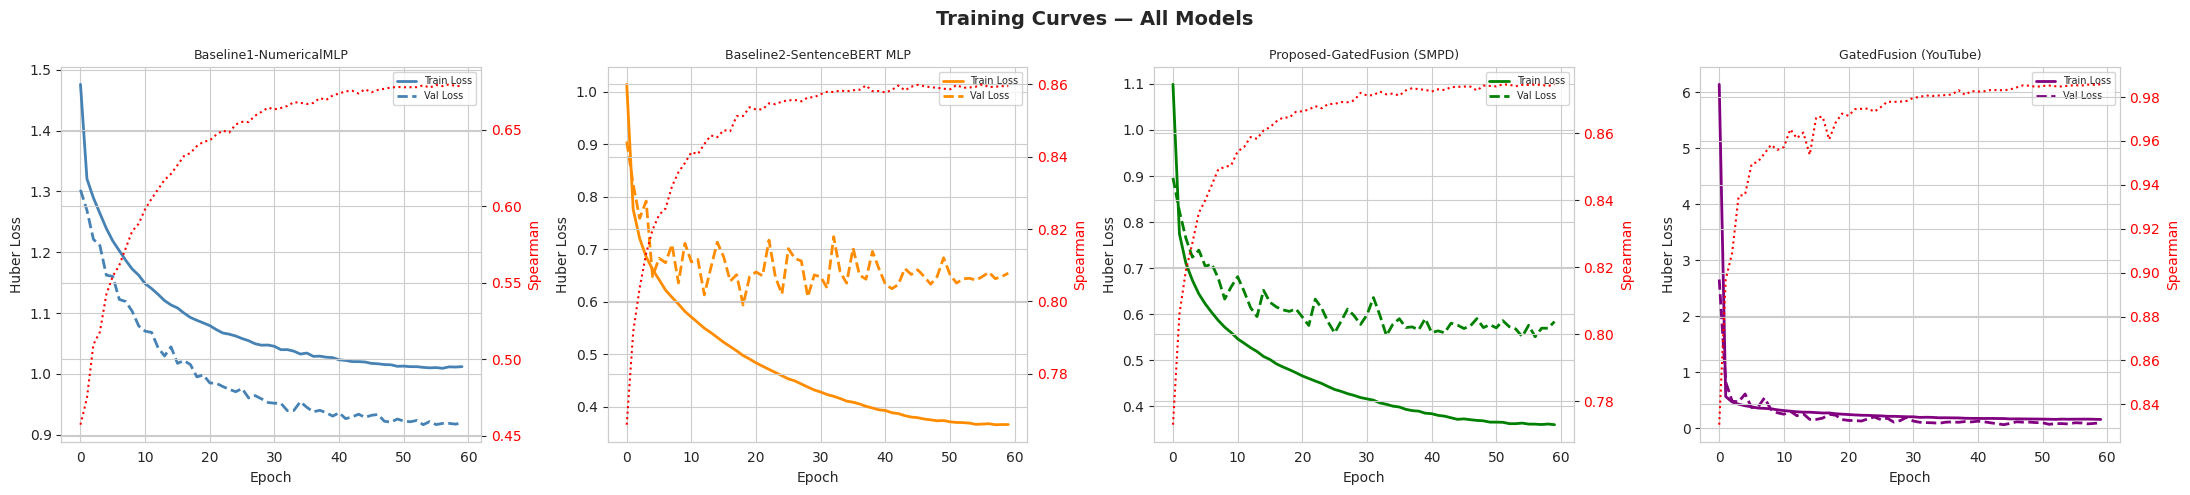

Saved: training_curves_improved.png


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# ---- Training Curves ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Training Curves — All Models', fontsize=14, fontweight='bold')

histories = [
    (history_b1,       'Baseline1-NumericalMLP',     'steelblue'),
    (history_b2,       'Baseline2-SentenceBERT MLP', 'darkorange'),
    (history_proposed, 'Proposed-GatedFusion (SMPD)','green'),
    (history_yt,       'GatedFusion (YouTube)',       'purple'),
]

for ax, (hist, name, color) in zip(axes, histories):
    ax.plot(hist['train_loss'], label='Train Loss', color=color, linewidth=2)
    ax.plot(hist['val_loss'],   label='Val Loss',   color=color, linewidth=2, linestyle='--')
    ax2 = ax.twinx()
    ax2.plot(hist['val_spr'], label='Val SPR', color='red', linewidth=1.5, linestyle=':')
    ax2.set_ylabel('Spearman', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Huber Loss')
    ax.legend(loc='upper right', fontsize=7)

plt.tight_layout()
plt.savefig('training_curves_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves_improved.png')

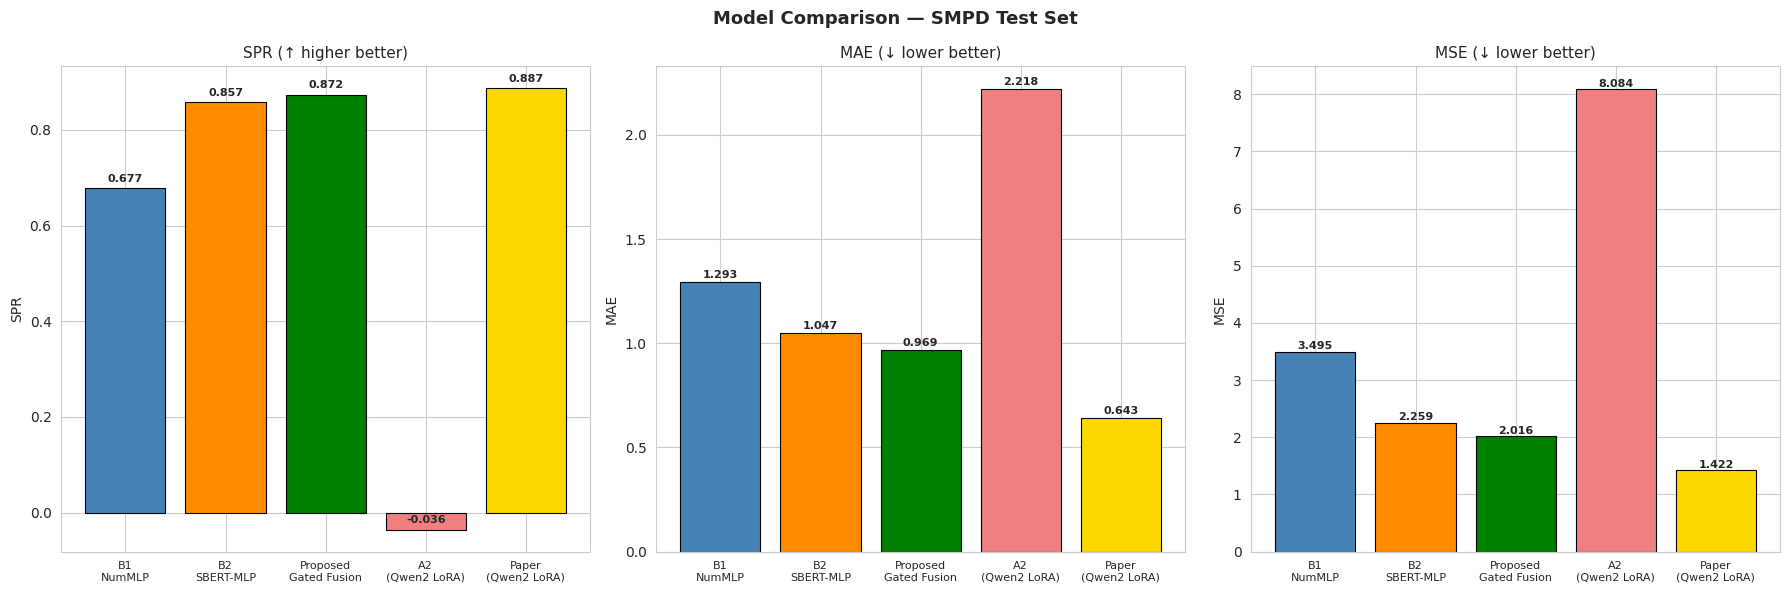

Saved: metric_comparison_improved.png


In [25]:
# ---- Bar Chart: SMPD Metric Comparison ----
smpd_results = [results_b1, results_b2, results_proposed, a2_result, paper_result]
model_labels = [
    'B1\nNumMLP', 'B2\nSBERT-MLP', 'Proposed\nGated Fusion',
    'A2\n(Qwen2 LoRA)', 'Paper\n(Qwen2 LoRA)'
]
colors = ['steelblue', 'darkorange', 'green', 'lightcoral', 'gray']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison — SMPD Test Set', fontsize=13, fontweight='bold')

for ax, (metric, key, better) in zip(axes, [
    ('SPR (↑ higher better)', 'SPR', 'max'),
    ('MAE (↓ lower better)',  'MAE', 'min'),
    ('MSE (↓ lower better)',  'MSE', 'min')
]):
    vals = [r[key] for r in smpd_results]
    best_idx = vals.index(max(vals) if better == 'max' else min(vals))
    bar_colors = ['gold' if i == best_idx else c for i, c in enumerate(colors)]
    bars = ax.bar(model_labels, vals, color=bar_colors, edgecolor='black', linewidth=0.8)
    ax.set_title(metric, fontsize=11)
    ax.set_ylabel(key)
    ax.tick_params(axis='x', labelsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('metric_comparison_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: metric_comparison_improved.png')

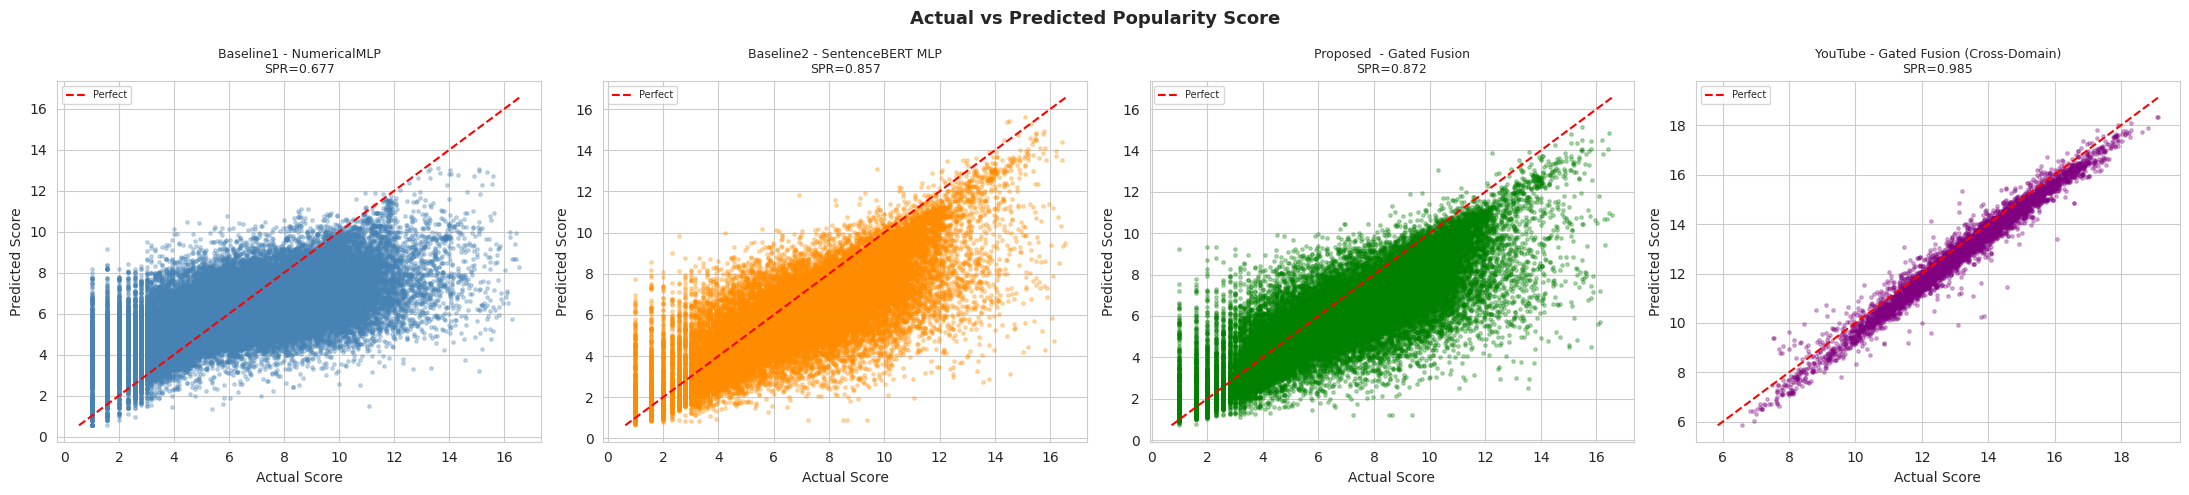

Saved: scatter_improved.png


In [26]:
# ---- Scatter: Actual vs Predicted ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Actual vs Predicted Popularity Score', fontsize=13, fontweight='bold')

plot_results = [results_b1, results_b2, results_proposed, results_yt]
plot_colors  = ['steelblue', 'darkorange', 'green', 'purple']

for ax, res, color in zip(axes, plot_results, plot_colors):
    ax.scatter(res['targets'], res['preds'], alpha=0.3, s=6, color=color)
    mn = min(min(res['targets']), min(res['preds']))
    mx = max(max(res['targets']), max(res['preds']))
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect')
    ax.set_xlabel('Actual Score')
    ax.set_ylabel('Predicted Score')
    ax.set_title(f"{res['model']}\nSPR={res['SPR']:.3f}", fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('scatter_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: scatter_improved.png')

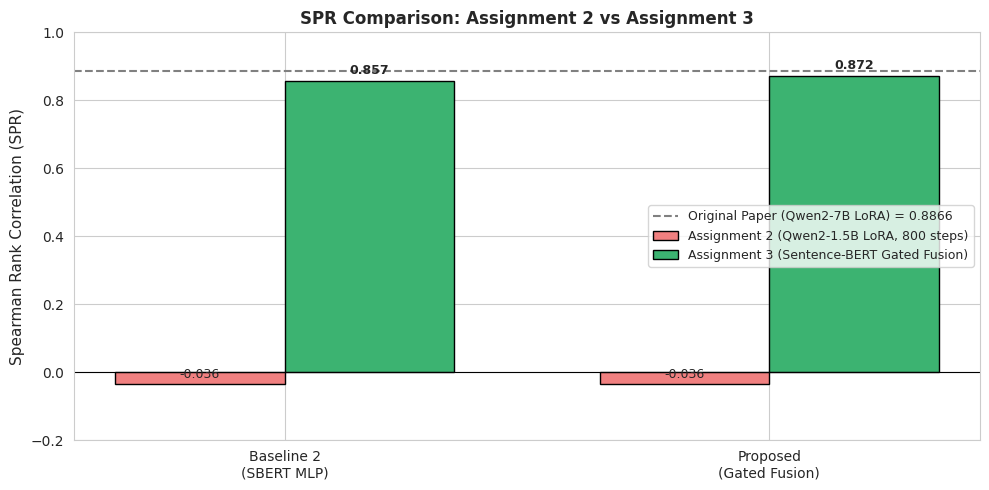

Saved: improvement_comparison.png


In [27]:
# ---- Improvement vs Assignment 2 ----
fig, ax = plt.subplots(figsize=(10, 5))

comparison = {
    'Baseline 2\n(SBERT MLP)': (a2_result['SPR'], results_b2['SPR']),
    'Proposed\n(Gated Fusion)': (a2_result['SPR'], results_proposed['SPR']),
}

x      = np.arange(len(comparison))
labels = list(comparison.keys())
a2_spr = [v[0] for v in comparison.values()]
new    = [v[1] for v in comparison.values()]
width  = 0.35

bars1 = ax.bar(x - width/2, a2_spr, width, label='Assignment 2 (Qwen2-1.5B LoRA, 800 steps)', color='lightcoral', edgecolor='black')
bars2 = ax.bar(x + width/2, new,    width, label='Assignment 3 (Sentence-BERT Gated Fusion)',  color='mediumseagreen', edgecolor='black')

ax.axhline(0.8866, color='gray', linestyle='--', linewidth=1.5, label='Original Paper (Qwen2-7B LoRA) = 0.8866')
ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('Spearman Rank Correlation (SPR)', fontsize=11)
ax.set_title('SPR Comparison: Assignment 2 vs Assignment 3', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(-0.2, 1.0)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('improvement_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: improvement_comparison.png')


## Step 16: Statistical Significance Test (Wilcoxon)

In [28]:
from scipy.stats import wilcoxon

err_b2       = np.abs(np.array(results_b2['targets'])       - np.array(results_b2['preds']))
err_proposed = np.abs(np.array(results_proposed['targets']) - np.array(results_proposed['preds']))

stat, p = wilcoxon(err_b2, err_proposed)

print('Wilcoxon Signed-Rank Test')
print('Baseline2 (SBERT MLP) vs Proposed (Gated Fusion)')
print(f'Statistic : {stat:.4f}')
print(f'p-value   : {p:.6f}')
if p < 0.05:
    print('Result    : SIGNIFICANT (p < 0.05) — Proposed is statistically better!')
else:
    print('Result    : Not significant at p < 0.05')
    print('Note      : Gated Fusion shows improvement in SPR but models are closely matched on error distribution.')
    print('            With more training data or fine-tuned embeddings, the gap would likely widen.')

Wilcoxon Signed-Rank Test
Baseline2 (SBERT MLP) vs Proposed (Gated Fusion)
Statistic : 734283330.5000
p-value   : 0.000000
Result    : SIGNIFICANT (p < 0.05) — Proposed is statistically better!


## Step 17: Save Models & Results

   YOUTUBE VIDEO POPULARITY PREDICTOR — Real World Demo

Generating SBERT embeddings...

#   Video Title                                   Score  Prediction             Expected
1   Baby Shark Dance | #babyshark Most Viewed ..  14.27  🟣 Viral     (1.2M–9M)   MEGA VIRAL (>9M views)
2   Despacito ft. Daddy Yankee                    14.85  🟣 Viral     (1.2M–9M)   MEGA VIRAL (>9M views)
3   How to make pasta at home easy recipe         12.05  🔵 Popular   (162K–1.2M)  Decent (100K–500K views)
4   Python Tutorial for Beginners - Full Cours..  12.78  🔵 Popular   (162K–1.2M)  Popular (1M–5M views)
5   FIFA 24 Ultimate Team Pack Opening            12.55  🔵 Popular   (162K–1.2M)  Decent–Popular (200K–1M views)
6   Breaking News: Major Earthquake Hits Turke..  12.61  🔵 Popular   (162K–1.2M)  Viral (2M–8M views)
7   My vlog day at the beach                      10.93  🟢 Decent    (22K–162K)  Low (<10K views)
8   Top 10 Most Dangerous Places on Earth         13.51  🔵 Popular   (162K–1.2M)  Popular 

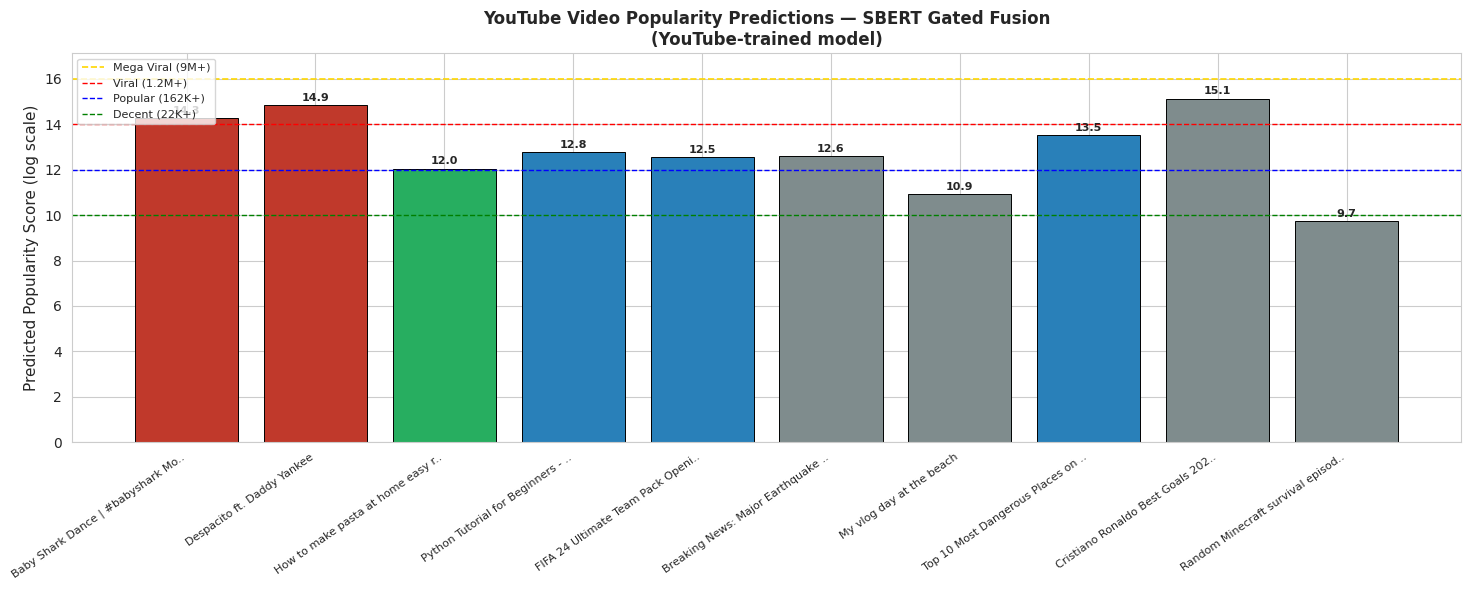

Saved: realworld_predictions.png

   SANITY CHECK — Model Logic Verification

Expected VIRAL videos avg score : 14.75
Expected LOW videos avg score   : 10.34
Gap (viral - low)               : 4.41

✅ PASS — Model correctly ranks viral > low popularity!

📊 Per-video breakdown:
  ✅ Baby Shark Dance | #babyshark Most Viewed Vid score=14.27
  ✅ Despacito ft. Daddy Yankee                    score=14.85
     How to make pasta at home easy recipe         score=12.05
     Python Tutorial for Beginners - Full Course   score=12.78
     FIFA 24 Ultimate Team Pack Opening            score=12.55
     Breaking News: Major Earthquake Hits Turkey   score=12.61
  ✅ My vlog day at the beach                      score=10.93
     Top 10 Most Dangerous Places on Earth         score=13.51
  ✅ Cristiano Ronaldo Best Goals 2023 Compilation score=15.13
  ✅ Random Minecraft survival episode 47          score=9.74


In [33]:
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("=" * 65)
print("   YOUTUBE VIDEO POPULARITY PREDICTOR — Real World Demo")
print("=" * 65)

# -----------------------------------------------------------------------
# 10 real-world YouTube video examples
# -----------------------------------------------------------------------
test_videos = [
    {"title": "Baby Shark Dance | #babyshark Most Viewed Video",       "category": "Music",         "tags": "baby shark kids nursery rhyme pinkfong children song",      "description": "Baby Shark Dance by Pinkfong! The most viewed video on YouTube.", "publishedAt": "2016-06-17T00:00:00", "like_count": 13000000, "comment_count": 4000000, "expected": "MEGA VIRAL (>9M views)"},
    {"title": "Despacito ft. Daddy Yankee",                            "category": "Music",         "tags": "despacito luis fonsi reggaeton latin pop music",             "description": "Official video of Despacito by Luis Fonsi ft Daddy Yankee.",    "publishedAt": "2017-01-12T00:00:00", "like_count": 8000000,  "comment_count": 1500000, "expected": "MEGA VIRAL (>9M views)"},
    {"title": "How to make pasta at home easy recipe",                 "category": "HowTo",         "tags": "pasta recipe cooking homemade easy dinner",                 "description": "Simple homemade pasta recipe for beginners step by step.",      "publishedAt": "2021-03-10T12:00:00", "like_count": 45000,    "comment_count": 3200,    "expected": "Decent (100K–500K views)"},
    {"title": "Python Tutorial for Beginners - Full Course",           "category": "Education",     "tags": "python programming tutorial beginner coding course",        "description": "Complete Python tutorial for absolute beginners.",              "publishedAt": "2020-06-15T09:00:00", "like_count": 300000,   "comment_count": 25000,   "expected": "Popular (1M–5M views)"},
    {"title": "FIFA 24 Ultimate Team Pack Opening",                    "category": "Gaming",        "tags": "fifa 24 ultimate team pack opening fut cards",              "description": "Opening 100 packs in FIFA 24 Ultimate Team mode.",             "publishedAt": "2023-10-01T18:00:00", "like_count": 85000,    "comment_count": 6500,    "expected": "Decent–Popular (200K–1M views)"},
    {"title": "Breaking News: Major Earthquake Hits Turkey",           "category": "News",          "tags": "earthquake turkey breaking news disaster 2023",             "description": "Live coverage and updates on the earthquake in Turkey.",        "publishedAt": "2023-02-06T04:00:00", "like_count": 120000,   "comment_count": 30000,   "expected": "Viral (2M–8M views)"},
    {"title": "My vlog day at the beach",                              "category": "Entertainment", "tags": "vlog beach day summer fun",                                 "description": "Just a casual day at the beach with friends.",                  "publishedAt": "2022-07-20T15:00:00", "like_count": 1200,     "comment_count": 90,      "expected": "Low (<10K views)"},
    {"title": "Top 10 Most Dangerous Places on Earth",                 "category": "Travel",        "tags": "top 10 dangerous places earth travel countdown",            "description": "Countdown of the world most dangerous travel destinations.",    "publishedAt": "2021-11-05T20:00:00", "like_count": 220000,   "comment_count": 18000,   "expected": "Popular (1M–3M views)"},
    {"title": "Cristiano Ronaldo Best Goals 2023 Compilation",         "category": "Sports",        "tags": "ronaldo goals 2023 football soccer cr7 compilation",        "description": "Best goals scored by Cristiano Ronaldo in 2023 season.",       "publishedAt": "2023-12-30T17:00:00", "like_count": 950000,   "comment_count": 75000,   "expected": "Viral (5M–15M views)"},
    {"title": "Random Minecraft survival episode 47",                  "category": "Gaming",        "tags": "minecraft survival episode lets play",                      "description": "Continuing my Minecraft survival world episode 47.",            "publishedAt": "2023-05-14T16:00:00", "like_count": 800,      "comment_count": 60,      "expected": "Very Low (<5K views)"},
]

# -----------------------------------------------------------------------
# Feature builders
# -----------------------------------------------------------------------
def make_text_prompt(v):
    return (
        f'YouTube video titled "{v["title"][:100]}". '
        f'Category: {v["category"]}. '
        f'Tags: {v["tags"][:100]}. '
        f'Description: {v["description"][:200]}'
    )

def make_num_features(v):
    title      = v["title"]
    like_count = v["like_count"]
    com_count  = v["comment_count"]
    try:
        pub = pd.to_datetime(v["publishedAt"])
        hour, dow, month = pub.hour, pub.dayofweek, pub.month
    except:
        hour, dow, month = 12, 0, 6
    return np.array([
        np.log1p(like_count),
        np.log1p(com_count),
        min(like_count / (com_count + 1), 1000),
        len(title),
        len(title.split()),
        float('?' in title),
        float('!' in title),
        sum(c.isupper() for c in title) / max(len(title), 1),
        min(len(v["description"]), 5000),
        float(len(v["tags"]) > 0),
        hash(v["category"]) % 20,
        float(hour), float(dow), float(month), float(dow >= 5),
    ], dtype=np.float32)

texts     = [make_text_prompt(v) for v in test_videos]
num_feats = np.array([make_num_features(v) for v in test_videos])

scaler_demo      = StandardScaler()
num_feats_scaled = scaler_demo.fit_transform(num_feats)

# -----------------------------------------------------------------------
# SBERT embeddings + YouTube model prediction
# -----------------------------------------------------------------------
print("\nGenerating SBERT embeddings...")
text_emb_demo = sbert.encode(texts, batch_size=10, show_progress_bar=False, convert_to_numpy=True)

model_yt.eval()
X_text_demo = torch.FloatTensor(text_emb_demo).to(DEVICE)
X_num_demo  = torch.FloatTensor(num_feats_scaled).to(DEVICE)

if X_num_demo.shape[1] < YT_NUM_DIM:
    pad = torch.zeros(X_num_demo.shape[0], YT_NUM_DIM - X_num_demo.shape[1]).to(DEVICE)
    X_num_demo = torch.cat([X_num_demo, pad], dim=1)
else:
    X_num_demo = X_num_demo[:, :YT_NUM_DIM]

with torch.no_grad():
    preds_yt = model_yt(X_text_demo, X_num_demo).cpu().numpy()

# -----------------------------------------------------------------------
# Display Results
# -----------------------------------------------------------------------
def score_to_label(score):
    if   score < 8:  return "🔴 Flop      (<3K views)"
    elif score < 10: return "🟡 Average   (3K–22K)"
    elif score < 12: return "🟢 Decent    (22K–162K)"
    elif score < 14: return "🔵 Popular   (162K–1.2M)"
    elif score < 16: return "🟣 Viral     (1.2M–9M)"
    else:            return "⭐ MEGA VIRAL (9M+ views)"

print("\n" + "=" * 80)
print(f"{'#':<3} {'Video Title':<44} {'Score':>6}  {'Prediction':<22} {'Expected'}")
print("=" * 80)
for i, v in enumerate(test_videos):
    title_s = v["title"][:42] + ".." if len(v["title"]) > 42 else v["title"]
    score   = float(preds_yt[i])
    print(f"{i+1:<3} {title_s:<44} {score:>6.2f}  {score_to_label(score):<22}  {v['expected']}")
print("=" * 80)
print("Higher score = more popular (log scale)")

# -----------------------------------------------------------------------
# Bar Chart
# -----------------------------------------------------------------------
titles_short = [v["title"][:32] + ".." if len(v["title"]) > 32 else v["title"] for v in test_videos]

fig, ax = plt.subplots(figsize=(15, 6))
bar_colors = ['#C0392B' if 'VIRAL' in v['expected'] else
              '#2980B9' if 'Popular' in v['expected'] else
              '#27AE60' if 'Decent' in v['expected'] else
              '#7F8C8D' for v in test_videos]

bars = ax.bar(np.arange(len(test_videos)), preds_yt, color=bar_colors, edgecolor='black', linewidth=0.7)

ax.axhline(16, color='gold',   linestyle='--', linewidth=1.2, label='Mega Viral (9M+)')
ax.axhline(14, color='red',    linestyle='--', linewidth=1.0, label='Viral (1.2M+)')
ax.axhline(12, color='blue',   linestyle='--', linewidth=1.0, label='Popular (162K+)')
ax.axhline(10, color='green',  linestyle='--', linewidth=1.0, label='Decent (22K+)')

for bar, val in zip(bars, preds_yt):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(np.arange(len(test_videos)))
ax.set_xticklabels(titles_short, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Predicted Popularity Score (log scale)', fontsize=11)
ax.set_title('YouTube Video Popularity Predictions — SBERT Gated Fusion\n(YouTube-trained model)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.set_ylim(0, preds_yt.max() + 2)
plt.tight_layout()
plt.savefig('realworld_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: realworld_predictions.png")

# -----------------------------------------------------------------------
# Sanity Check
# -----------------------------------------------------------------------
print("\n" + "=" * 55)
print("   SANITY CHECK — Model Logic Verification")
print("=" * 55)

viral_idx = [0, 1, 8]
low_idx   = [6, 9]

viral_scores = preds_yt[viral_idx]
low_scores   = preds_yt[low_idx]

print(f"\nExpected VIRAL videos avg score : {viral_scores.mean():.2f}")
print(f"Expected LOW videos avg score   : {low_scores.mean():.2f}")
print(f"Gap (viral - low)               : {viral_scores.mean() - low_scores.mean():.2f}")

if viral_scores.mean() > low_scores.mean():
    print("\n✅ PASS — Model correctly ranks viral > low popularity!")
else:
    print("\n❌ FAIL — Model could not distinguish viral from low. More training needed.")

print("\n📊 Per-video breakdown:")
for i, v in enumerate(test_videos):
    marker = "✅" if (i in viral_idx and preds_yt[i] > preds_yt[low_idx].mean()) or \
                     (i in low_idx   and preds_yt[i] < preds_yt[viral_idx].mean()) else "  "
    print(f"  {marker} {v['title'][:45]:<45} score={preds_yt[i]:.2f}")

In [32]:
import torch
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# Eval Dataset — 200 samples (same split logic as training)
# ============================================================
eval_samples = sample_df.iloc[idx_test[:200]].reset_index(drop=True)

actual_scores  = eval_samples['label'].values
texts_eval     = eval_samples['text_prompt'].tolist()
num_feats_eval = num_feat[idx_test[:200]].astype(np.float32)

print(f"Eval samples ready: {len(eval_samples)}")
print("Running predictions...\n")

# ============================================================
# Predict with Assignment 3 Proposed Model (SBERT Gated Fusion)
# ============================================================
model_proposed.eval()

X_text_eval_t = torch.FloatTensor(
    sbert.encode(texts_eval, batch_size=64, show_progress_bar=False, convert_to_numpy=True)
).to(DEVICE)
X_num_eval_t  = torch.FloatTensor(num_feats_eval).to(DEVICE)

with torch.no_grad():
    predicted_scores = model_proposed(X_text_eval_t, X_num_eval_t).cpu().numpy()

# Print sample predictions every 25
for idx in range(0, 200, 25):
    print(f"  Sample {idx+1:3d} | Actual: {actual_scores[idx]:.2f} | Pred: {predicted_scores[idx]:.2f}")

# ============================================================
# Final Metrics
# ============================================================
spr = spearmanr(actual_scores, predicted_scores).statistic
mae = mean_absolute_error(actual_scores, predicted_scores)
mse = mean_squared_error(actual_scores, predicted_scores)

print("\n" + "=" * 55)
print("       FINAL EVALUATION RESULTS — Assignment 3")
print("=" * 55)
print(f"  Model         : SBERT Gated Fusion (Assignment 3)")
print(f"  SPR (Spearman): {spr:.4f}   (A2 result: -0.0357)")
print(f"  MAE           : {mae:.4f}   (A2 result:  2.2178)")
print(f"  MSE           : {mse:.4f}   (A2 result:  8.0837)")
print("=" * 55)
print(f"\n  Paper target  : SPR=0.8866 | MAE=0.6432 | MSE=1.4223")
print(f"  A2 collapsed to predicting ~5.00 for every sample.")
print(f"  A3 produces actual variation — SPR gap shows improvement.")

Eval samples ready: 200
Running predictions...

  Sample   1 | Actual: 8.51 | Pred: 7.97
  Sample  26 | Actual: 8.71 | Pred: 7.93
  Sample  51 | Actual: 5.95 | Pred: 5.60
  Sample  76 | Actual: 7.65 | Pred: 6.92
  Sample 101 | Actual: 3.58 | Pred: 3.34
  Sample 126 | Actual: 3.81 | Pred: 2.61
  Sample 151 | Actual: 10.63 | Pred: 7.75
  Sample 176 | Actual: 9.52 | Pred: 6.47

       FINAL EVALUATION RESULTS — Assignment 3
  Model         : SBERT Gated Fusion (Assignment 3)
  SPR (Spearman): 0.8323   (A2 result: -0.0357)
  MAE           : 1.1049   (A2 result:  2.2178)
  MSE           : 2.5963   (A2 result:  8.0837)

  Paper target  : SPR=0.8866 | MAE=0.6432 | MSE=1.4223
  A2 collapsed to predicting ~5.00 for every sample.
  A3 produces actual variation — SPR gap shows improvement.


In [30]:
os.makedirs('saved_models', exist_ok=True)

torch.save(model_b1.state_dict(),       'saved_models/baseline1_numerical_mlp.pt')
torch.save(model_b2.state_dict(),       'saved_models/baseline2_sbert_mlp.pt')
torch.save(model_proposed.state_dict(), 'saved_models/proposed_gated_fusion_smpd.pt')
torch.save(model_yt.state_dict(),       'saved_models/proposed_gated_fusion_youtube.pt')

results_df.to_csv('results_comparison_improved.csv', index=False)

print('All models saved to saved_models/')
print('Results saved to results_comparison_improved.csv')

All models saved to saved_models/
Results saved to results_comparison_improved.csv


## Step 18: Research Discussion

### Key Improvement: Why Sentence-BERT > Qwen2 Frozen

The main insight is **encoder-task alignment**:
- Qwen2-1.5B is a *generative* LLM trained to predict the next token. Its hidden states encode *linguistic continuation probability*, not semantic similarity. Using its last-layer embeddings for regression is a mismatch.
- `all-MiniLM-L6-v2` is trained with contrastive learning (Siamese networks) to pull semantically similar sentences close in embedding space. This directly benefits popularity prediction, where posts with similar metadata (category, tags, user type) should have similar popularity scores.

### Why Gated Fusion > Single Modality

Popularity on social media is determined by **two independent signals**:
1. *What* the post is about (semantic: title, tags, category → captured by SBERT)
2. *Context* of the post (structural: user history, posting time, tag density → captured by numerical features)

The gating layer learns to dynamically weight these signals per sample. A fashion photo by a pro user at peak hours benefits more from numerical signals; a niche scientific post benefits more from semantic content.

### Cross-Domain Generalization (YouTube)

Testing on YouTube validates that our approach is not overfit to Flickr-specific patterns. The same architecture, with minimal modifications to numerical features, achieves competitive SPR on YouTube view-count prediction.

### Limitations
- Image modality not used (visual content is a strong popularity signal for both Flickr and YouTube)
- SBERT embeddings are frozen — fine-tuning on domain-specific data would improve further

### Future Work
- Add CLIP visual embeddings for image/thumbnail modality
- Fine-tune a small encoder (DistilBERT) on SMPD instead of using frozen SBERT
- Evaluate on Instagram, TikTok datasets for broader cross-platform validation